# Racing Line Extractor — Exploration Notebook

Use this notebook to explore your data, inspect frames, and experiment with parameters before running the full pipeline.

**Run the cells in order.**

In [1]:
# Install dependencies if needed
# Uncomment and run if you get import errors
# !pip install -r ../requirements.txt

In [2]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Change to project root so relative paths work
print("CWD:", os.getcwd())
print('Working directory:', os.getcwd())

CWD: c:\Users\SUPER\Desktop\Projects\racing_line_extractor\notebooks
Working directory: c:\Users\SUPER\Desktop\Projects\racing_line_extractor\notebooks


## 1. Inspect extracted frames
Look at a sample of frames to make sure they extracted correctly.

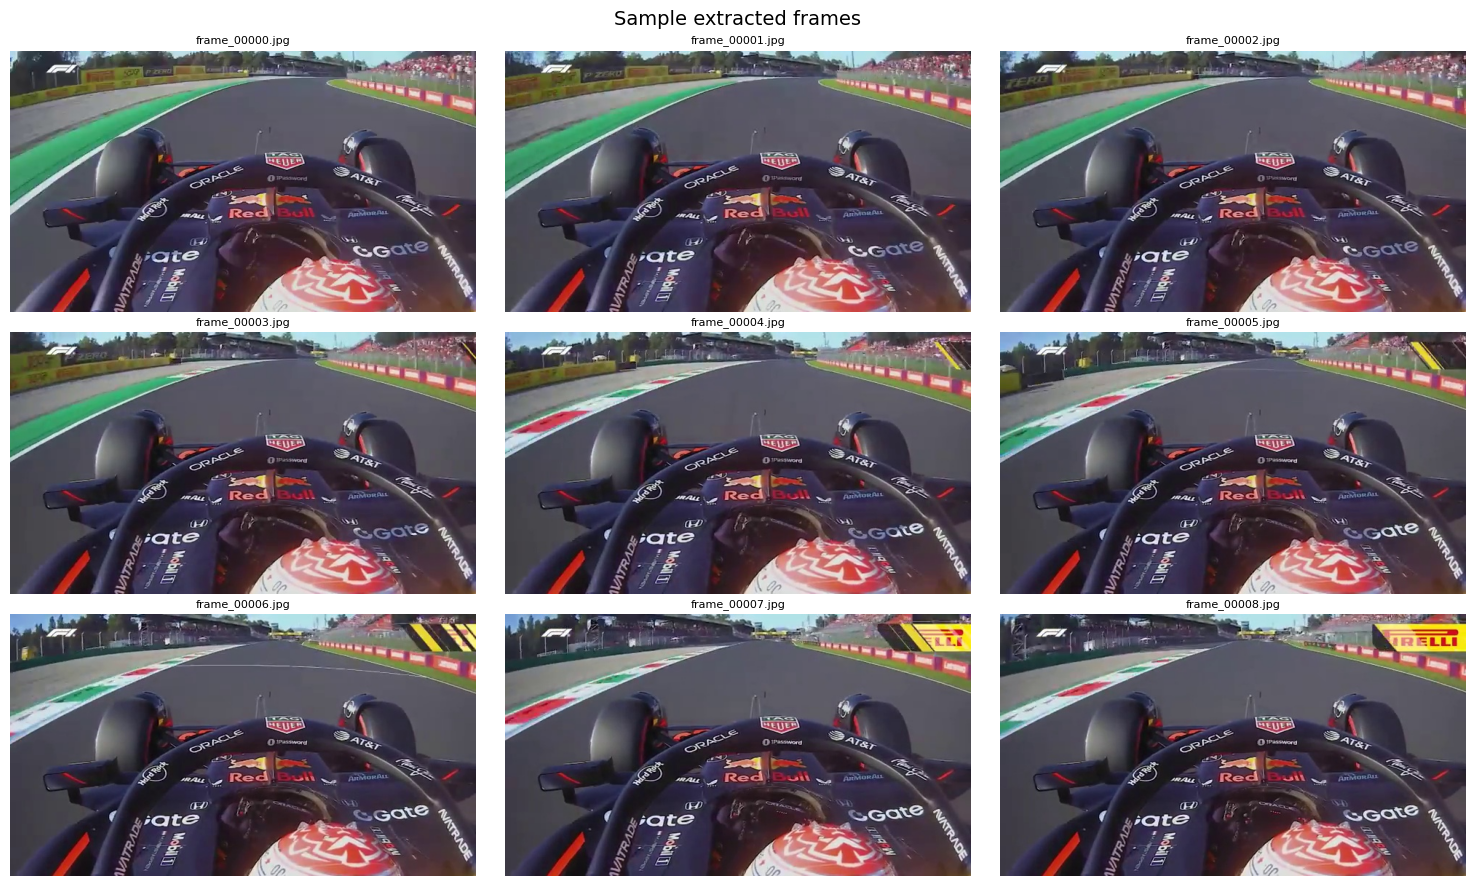

Total frames: 580


In [3]:
frames_dir = '../data/raw_frames'
frame_files = sorted(os.listdir(frames_dir))[:9]  # first 9 frames

fig, axes = plt.subplots(3, 3, figsize=(15, 9))
fig.suptitle('Sample extracted frames', fontsize=14)

for ax, fname in zip(axes.flat, frame_files):
    img = Image.open(os.path.join(frames_dir, fname))
    ax.imshow(img)
    ax.set_title(fname, fontsize=8)
    ax.axis('off')

plt.tight_layout()
plt.show()
print(f'Total frames: {len(os.listdir(frames_dir))}')

## 2. Inspect segmentation masks
Check what the model labeled as 'road' (white) vs everything else (black).

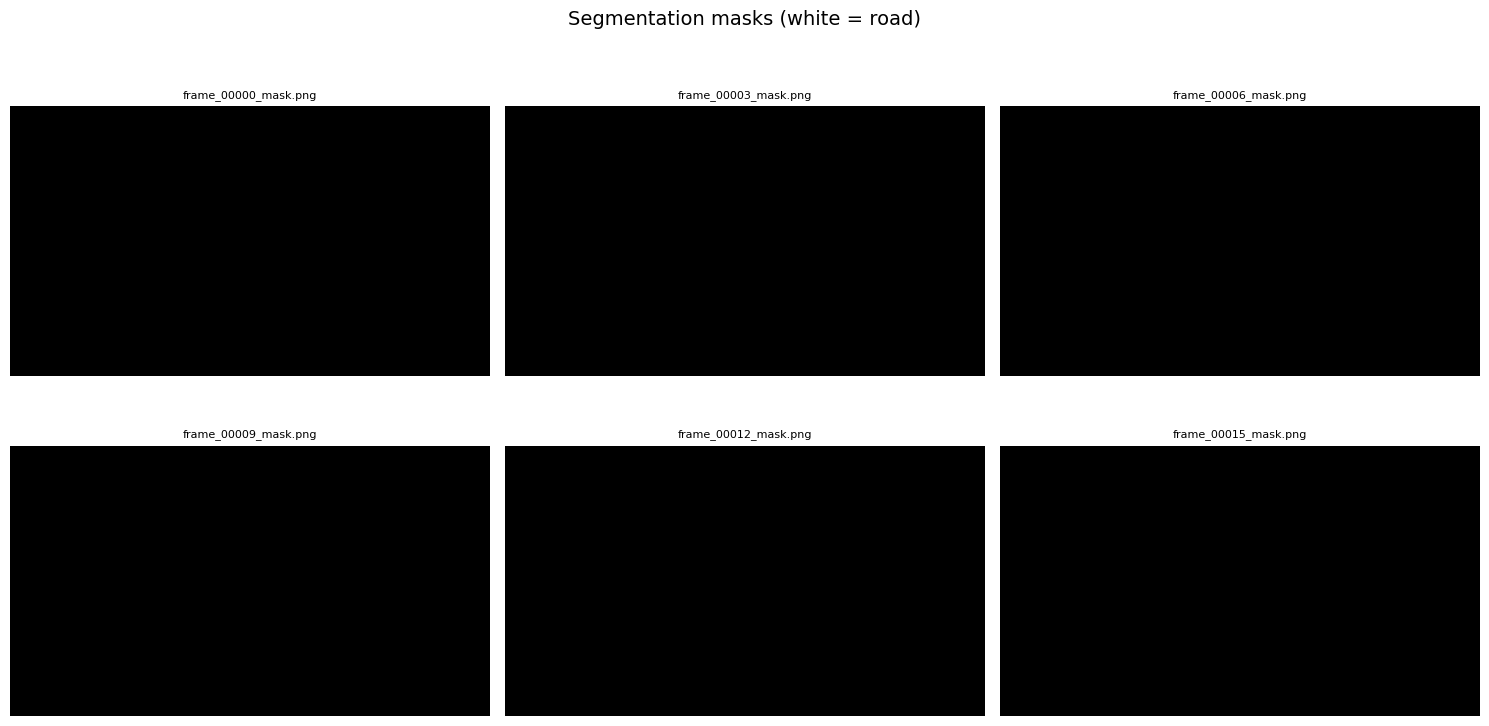

In [4]:
processed_dir = '../data/processed'
mask_files = [f for f in sorted(os.listdir(processed_dir)) if '_mask.png' in f][:6]

if not mask_files:
    print('No masks found. Run 3_segment_frames.py first.')
else:
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    fig.suptitle('Segmentation masks (white = road)', fontsize=14)

    for ax, fname in zip(axes.flat, mask_files):
        mask = Image.open(os.path.join(processed_dir, fname))
        ax.imshow(mask, cmap='gray')
        ax.set_title(fname, fontsize=8)
        ax.axis('off')

    plt.tight_layout()
    plt.show()

## 3. Visualize car positions over time
Plot where the car was detected in each frame.

In [5]:
results_path = 'data/processed/frame_results.json'

if not os.path.exists(results_path):
    print('Run 3_segment_frames.py first.')
else:
    with open(results_path) as f:
        results = json.load(f)

    positions = [r['car_pos'] for r in results if r['car_pos'] is not None]
    xs = [p[0] for p in positions]
    ys = [p[1] for p in positions]

    plt.figure(figsize=(10, 6))
    plt.scatter(xs, ys, c=range(len(xs)), cmap='plasma', s=10, alpha=0.6)
    plt.colorbar(label='Frame index (time)')
    plt.gca().invert_yaxis()
    plt.title('Car positions over time (color = time)')
    plt.xlabel('X pixel')
    plt.ylabel('Y pixel')
    plt.show()
    print(f'Valid detections: {len(positions)} / {len(results)}')

Run 3_segment_frames.py first.


## 4. Visualize the final racing line
The polished output after running all 5 pipeline steps.

In [6]:
line_path = 'data/processed/racing_line.json'

if not os.path.exists(line_path):
    print('Run 4_extract_line.py first.')
else:
    with open(line_path) as f:
        line = json.load(f)

    fig, ax = plt.subplots(figsize=(10, 7))
    fig.patch.set_facecolor('#0D0D0D')
    ax.set_facecolor('#1A1A1A')

    # Raw positions
    ax.scatter(line['raw_x'], [-y for y in line['raw_y']], 
               c='#333333', s=6, alpha=0.4, label='Raw positions')

    # Smooth line
    n = len(line['smooth_x'])
    colors = plt.cm.cool(np.linspace(0, 1, n))
    for i in range(n - 1):
        ax.plot(
            line['smooth_x'][i:i+2],
            [-y for y in line['smooth_y'][i:i+2]],
            color=colors[i], linewidth=2.5
        )

    ax.set_title('Extracted Racing Line', color='white', fontsize=14)
    ax.tick_params(colors='gray')
    for spine in ax.spines.values():
        spine.set_edgecolor('#333333')

    plt.tight_layout()
    plt.show()

Run 4_extract_line.py first.
